# Listen what you won't — Basic Experiment

This notebook goes through this process:

1. Generate a random network with assigned opinions
2. Apply HK model until convergence
3. Apply rewiring to force echo chambers
4. Visualize the network and metrics through each phase.
---

## 0 · Imports

In [32]:
import numpy as np
import matplotlib.pyplot as plt

from network_gen   import make_network, get_opinions
from hk_dynamics   import hk_run_history, opinion_variance, n_clusters, polarization_index
from simulation    import run_simulation, compute_metrics
from visualization import (
    plot_network_opinion,
    plot_network_community,
    plot_snapshots,
    plot_metrics,
    plot_opinion_histogram,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

---
## 1 · Generate the network

We create a network Barabási-Albert with **200 nodos** and **uniform** opinion distribution between [0, 1].

Parameters:

| Parameter | Options |
|-----------|----------|
| `model`   | `"BA"`, `"ER"`, `"WS"` |
| `opinion` | `"uniform"`, `"bimodal"`, `"clustered"` |
| `n`       | number of nodes |
| `m`       | (BA) edges for each new node |

In [33]:
G = make_network(
    model   = "BA",
    n       = 200,
    m       = 3,
    opinion = "uniform",
    seed    = 42,
)

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Graph average: {np.mean([d for _, d in G.degree()]):.2f}")
print(f"Initial average opinion: {get_opinions(G).mean():.3f}")
print(f"Initial variance: {get_opinions(G).var():.3f}")

Nodes: 200
Edges: 591
Graph average: 5.91
Initial average opinion: 0.494
Initial variance: 0.079


### Initial network — colored for opinion

🟥 = opinion closest to 0 · 🟩 = opinion closest to 1

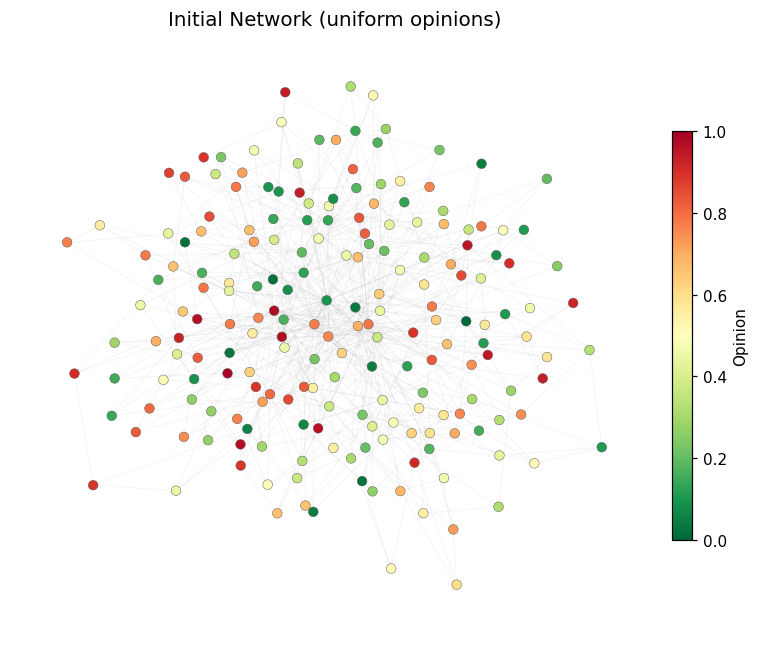

In [34]:
pos = plot_network_opinion(G, title="Initial Network (uniform opinions)", layout="spring")

---
## 2 · Model HK — only opinion convergence (without network changes)

Here we can see how HK works without modifying the structure of the network.
Only actualize opinions until system convergence

The key parameter is **ε (epsilon)**:  
- ε small → more clusters, high polarization 
- ε big → consensus

In [35]:
EPSILON = 0.45  

result_hk_only = run_simulation(
    G,
    epsilon      = EPSILON,
    rewire       = False,   # without rewiring
    max_hk_steps = 500,
    seed         = 42,
)

op_initial  = result_hk_only["snapshots"][0][1]
op_converged = result_hk_only["snapshots"][1][1]

print(f"ε = {EPSILON}")
print(f"Steps to convergence: {result_hk_only['phases'][0]['steps']}")
print(f"Opinion clusters: {n_clusters(op_converged)}")
print(f"Final variance: {opinion_variance(op_converged):.4f}")
print(f"Polarization Index: {polarization_index(op_converged):.4f}  (0=consenso, 1=máximo)")

ε = 0.45
Steps to convergence: 38
Opinion clusters: 2
Final variance: 0.0012
Polarization Index: 0.0047  (0=consenso, 1=máximo)


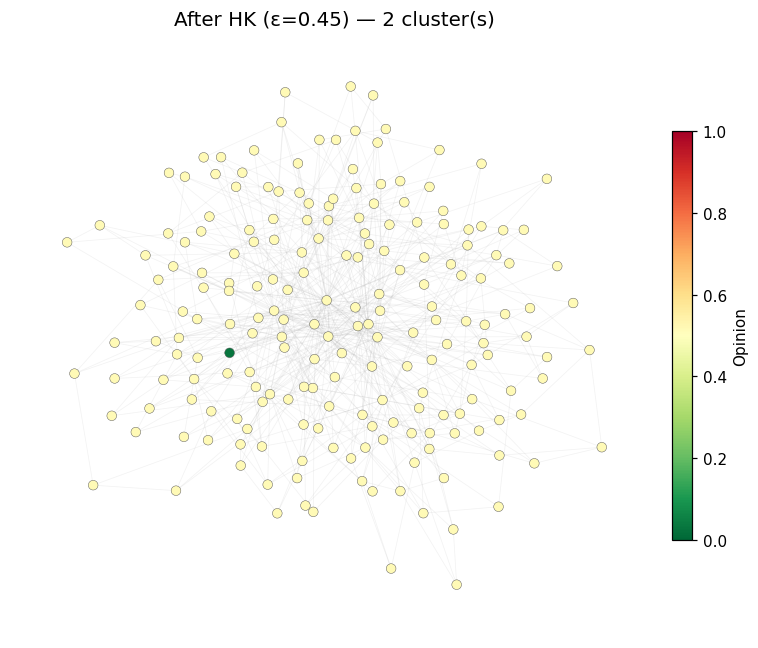

{0: array([-0.07351908, -0.014189  ]),
 1: array([0.15202491, 0.0366515 ]),
 2: array([-0.16332365, -0.29879402]),
 3: array([ 0.07579431, -0.02111497]),
 4: array([-0.03147911,  0.07617148]),
 5: array([-0.21182596,  0.03711054]),
 6: array([-0.02606098, -0.06069757]),
 7: array([ 0.11200968, -0.01404186]),
 8: array([-0.11041187,  0.18089678]),
 9: array([0.03642509, 0.24624496]),
 10: array([ 0.14291435, -0.0632991 ]),
 11: array([-0.53885734, -0.06591763]),
 12: array([0.14894201, 0.10022817]),
 13: array([0.09989555, 0.32906506]),
 14: array([ 0.16025741, -0.30105695]),
 15: array([ 0.09157529, -0.35715758]),
 16: array([-0.07889922, -0.25559091]),
 17: array([-0.1108037 , -0.39399362]),
 18: array([-0.47448874, -0.14116544]),
 19: array([-0.29586253, -0.1951736 ]),
 20: array([-0.26610316,  0.0099104 ]),
 21: array([-0.3485045 ,  0.25261038]),
 22: array([-0.18525961, -0.06190979]),
 23: array([-0.27451035, -0.25160136]),
 24: array([-0.36331453, -0.01343422]),
 25: array([-0.116

In [36]:
plot_network_opinion(
    result_hk_only["G"],
    opinions = op_converged,
    title    = f"After HK (ε={EPSILON}) — {n_clusters(op_converged)} cluster(s)",
    pos      = pos,
)

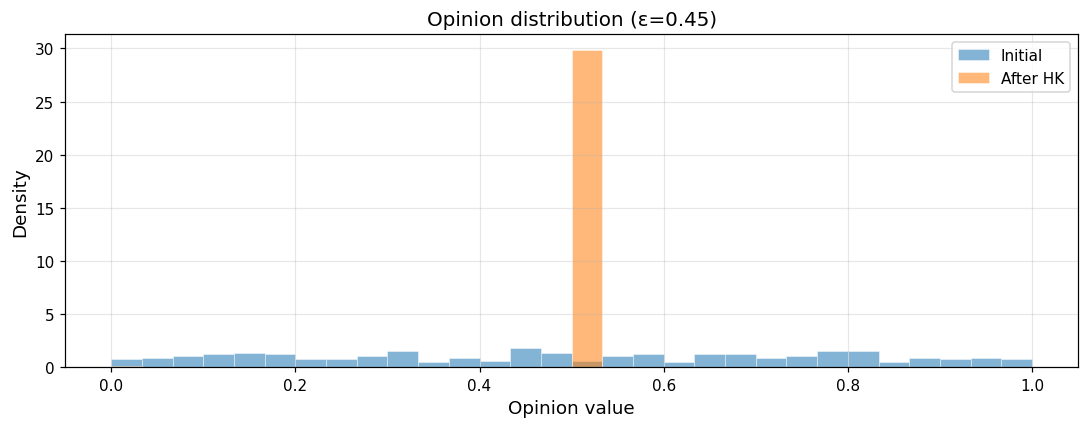

In [37]:
plot_opinion_histogram({
    "Initial"    : op_initial,
    "After HK"    : op_converged,
}, title=f"Opinion distribution (ε={EPSILON})")

### Evaluation of ε performance

We explore diffenrent epsilon values with the same network and we see how the variance change.

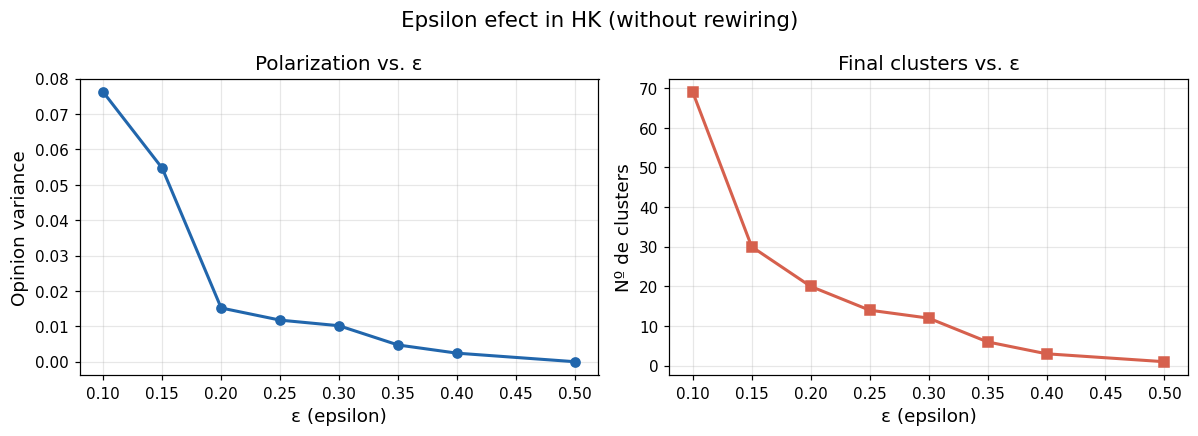

In [38]:
epsilons = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
variances = []
num_clusters = []

for eps in epsilons:
    r = run_simulation(G, epsilon=eps, rewire=False, seed=42)
    final_op = r["snapshots"][-1][1]
    variances.append(opinion_variance(final_op))
    num_clusters.append(n_clusters(final_op))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(epsilons, variances, "o-", color="#2166ac", linewidth=2)
ax1.set_xlabel("ε (epsilon)", fontsize=12)
ax1.set_ylabel("Opinion variance", fontsize=12)
ax1.set_title("Polarization vs. ε", fontsize=13)
ax1.grid(True, alpha=0.3)

ax2.plot(epsilons, num_clusters, "s-", color="#d6604d", linewidth=2)
ax2.set_xlabel("ε (epsilon)", fontsize=12)
ax2.set_ylabel("Nº de clusters", fontsize=12)
ax2.set_title("Final clusters vs. ε", fontsize=13)
ax2.yaxis.get_major_locator().set_params(integer=True)
ax2.grid(True, alpha=0.3)

plt.suptitle("Epsilon efect in HK (without rewiring)", fontsize=14)
plt.tight_layout()
plt.show()

## 3 · HK + Homophilic Rewiring → Echo Chambers

Now we activate rewiring: in each round, edges between nodes with **distant opinions** are removed and replaced with edges between nodes holding **similar opinions**. The network reconfigures itself to isolate groups. Humanity reinventing tribalism with extra steps. Remarkable species.

Rewiring parameters:

| Parameter | Effect |
|-----------|--------|
| `p_rewire` | Probability of cutting each discordant edge per round. Higher values → faster rewiring. |
| `rewire_steps` | Number of rewiring rounds. Higher values → stronger fragmentation. |
| `hk_steps_per_rewire` | Number of HK steps between rewiring rounds. |

In [39]:
result = run_simulation(
    G,
    epsilon             = 0.05,
    rewire              = True,
    p_rewire            = 0.05,    
    rewire_steps        = 60,
    hk_steps_per_rewire = 5,
    seed                = 42,
)

op_final = result["snapshots"][-1][1]

print(f"Clusters final opinions: {n_clusters(op_final)}")
print(f"Final variance: {opinion_variance(op_final):.4f}")
print(f"Polarization Index: {polarization_index(op_final):.4f}")

mod    = result["metrics"].get("modularity",    [float("nan")])[-1]
n_comm = result["metrics"].get("n_communities", [float("nan")])[-1]
if not np.isnan(mod):
    print(f"Final Modularity: {mod:.4f}")
    print(f"Detected Communities: {int(n_comm)}")
else:
    print("Modularity: N/A  (install python-louvain to activate it)")


Clusters final opinions: 15
Final variance: 0.0788
Polarization Index: 0.3153
Final Modularity: 0.8106
Detected Communities: 14


### Snapshots: evolución de la red en el tiempo

Tres momentos: estado inicial → tras HK puro → tras rewiring.

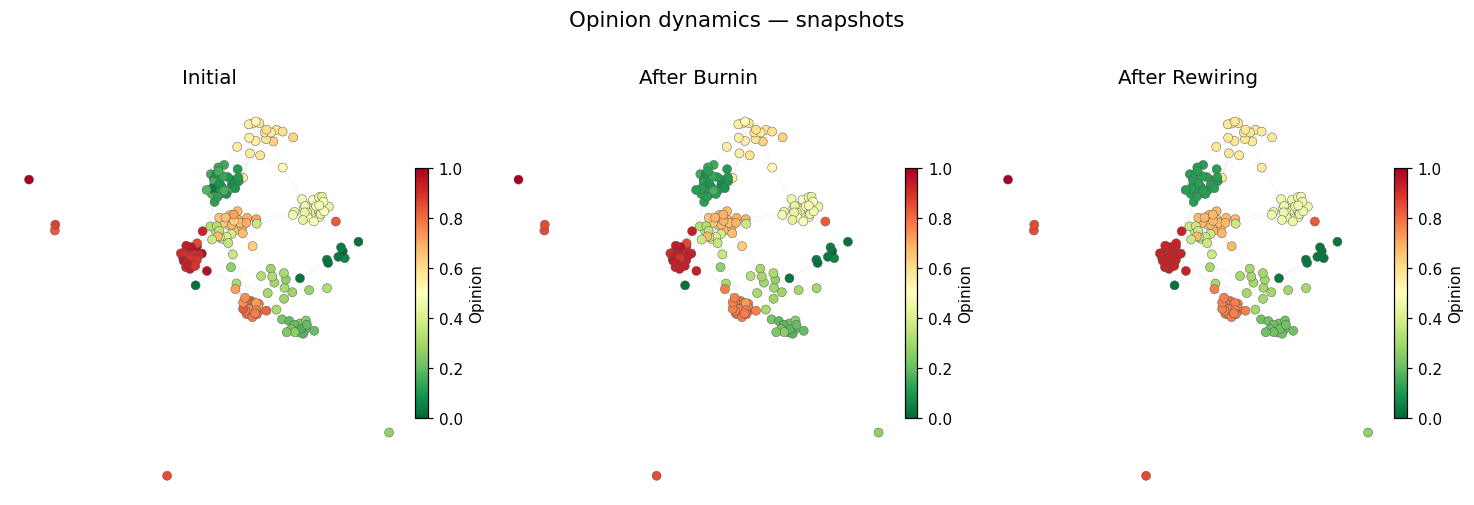

In [40]:
plot_snapshots(
    result["G"],
    result["snapshots"],
    layout   = "spring",
    color_by = "opinion",
)

### Communities Detected by Louvain — After Rewiring

Each color represents a distinct community detected automatically.  
The more isolated communities there are, the stronger the fragmentation.

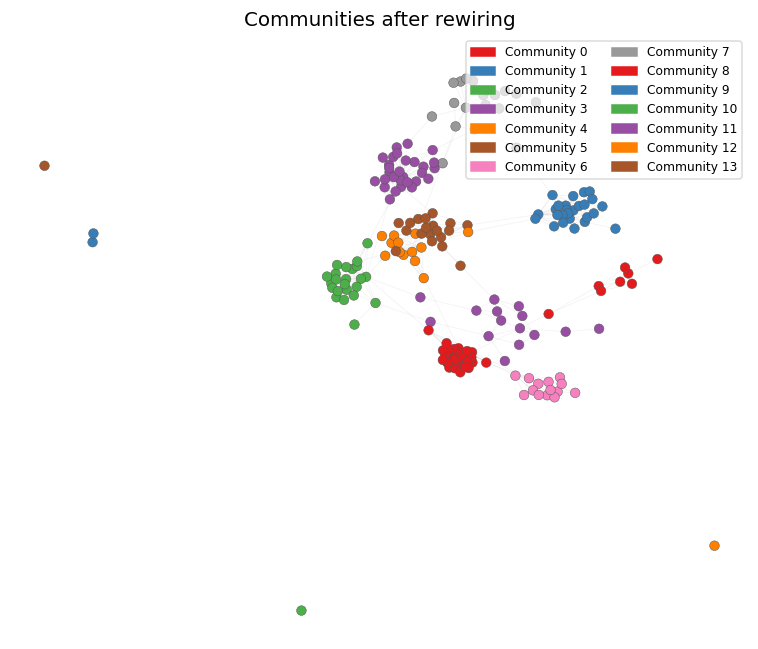

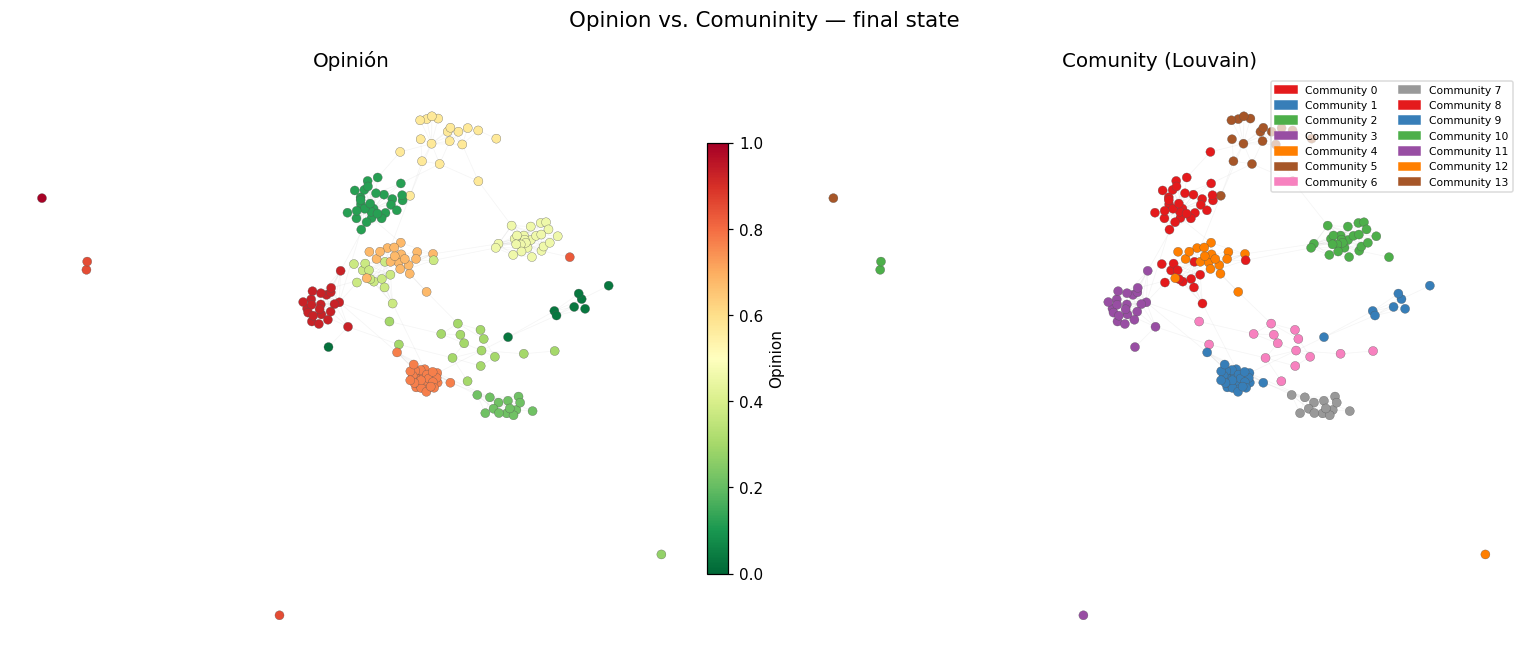

Final Modularity:      0.8106
Detected Communities: 14


In [41]:
plot_network_community(
    result["G"],
    title  = "Communities after rewiring",
    layout = "spring",
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
import copy, networkx as nx
G_final = result["G"]
op_final_arr = result["snapshots"][-1][1]

from visualization import _get_layout, _opinion_colors, _community_colors
import matplotlib.cm as cm, matplotlib.colors as mcolors, matplotlib.patches as mpatches

from networkx.algorithms.community import greedy_modularity_communities as _nx_comm
from networkx.algorithms.community import modularity as _nx_mod

G_final = result["G"]
op_final_arr = result["snapshots"][-1][1]

communities = list(_nx_comm(G_final))
partition = {}
for cid, comm in enumerate(communities):
    for node in comm:
        partition[node] = cid
nx.set_node_attributes(G_final, partition, "community")


pos_final = _get_layout(G_final, None, "spring")

colors_op = _opinion_colors(op_final_arr)
nx.draw_networkx_edges(G_final, pos_final, ax=ax1, alpha=0.12, edge_color="#aaa", width=0.5)
nx.draw_networkx_nodes(G_final, pos_final, ax=ax1, node_color=colors_op, node_size=35, linewidths=0.2, edgecolors="#555")
sm = cm.ScalarMappable(norm=mcolors.Normalize(0,1), cmap="RdYlGn_r")
plt.colorbar(sm, ax=ax1, fraction=0.03, pad=0.02).set_label("Opinion")
ax1.set_title("Opinión", fontsize=13); ax1.axis("off")

# Panel derecho — comunidad
colors_comm, color_map = _community_colors(G_final)
nx.draw_networkx_edges(G_final, pos_final, ax=ax2, alpha=0.12, edge_color="#aaa", width=0.5)
nx.draw_networkx_nodes(G_final, pos_final, ax=ax2, node_color=colors_comm, node_size=35, linewidths=0.2, edgecolors="#555")
patches = [mpatches.Patch(color=c, label=f"Community {k}") for k, c in color_map.items()]
ax2.legend(handles=patches, fontsize=7, loc="upper right", ncol=2, framealpha=0.7)
ax2.set_title("Comunity (Louvain)", fontsize=13); ax2.axis("off")

plt.suptitle("Opinion vs. Comuninity — final state", fontsize=14)
plt.tight_layout()
plt.show()

# Resumen numérico
mod    = result["metrics"].get("modularity",    [float("nan")])[-1]
n_comm = result["metrics"].get("n_communities", [float("nan")])[-1]
if not np.isnan(mod):
    print(f"Final Modularity:      {mod:.4f}")
    print(f"Detected Communities: {int(n_comm)}")


### Metrics through simulation

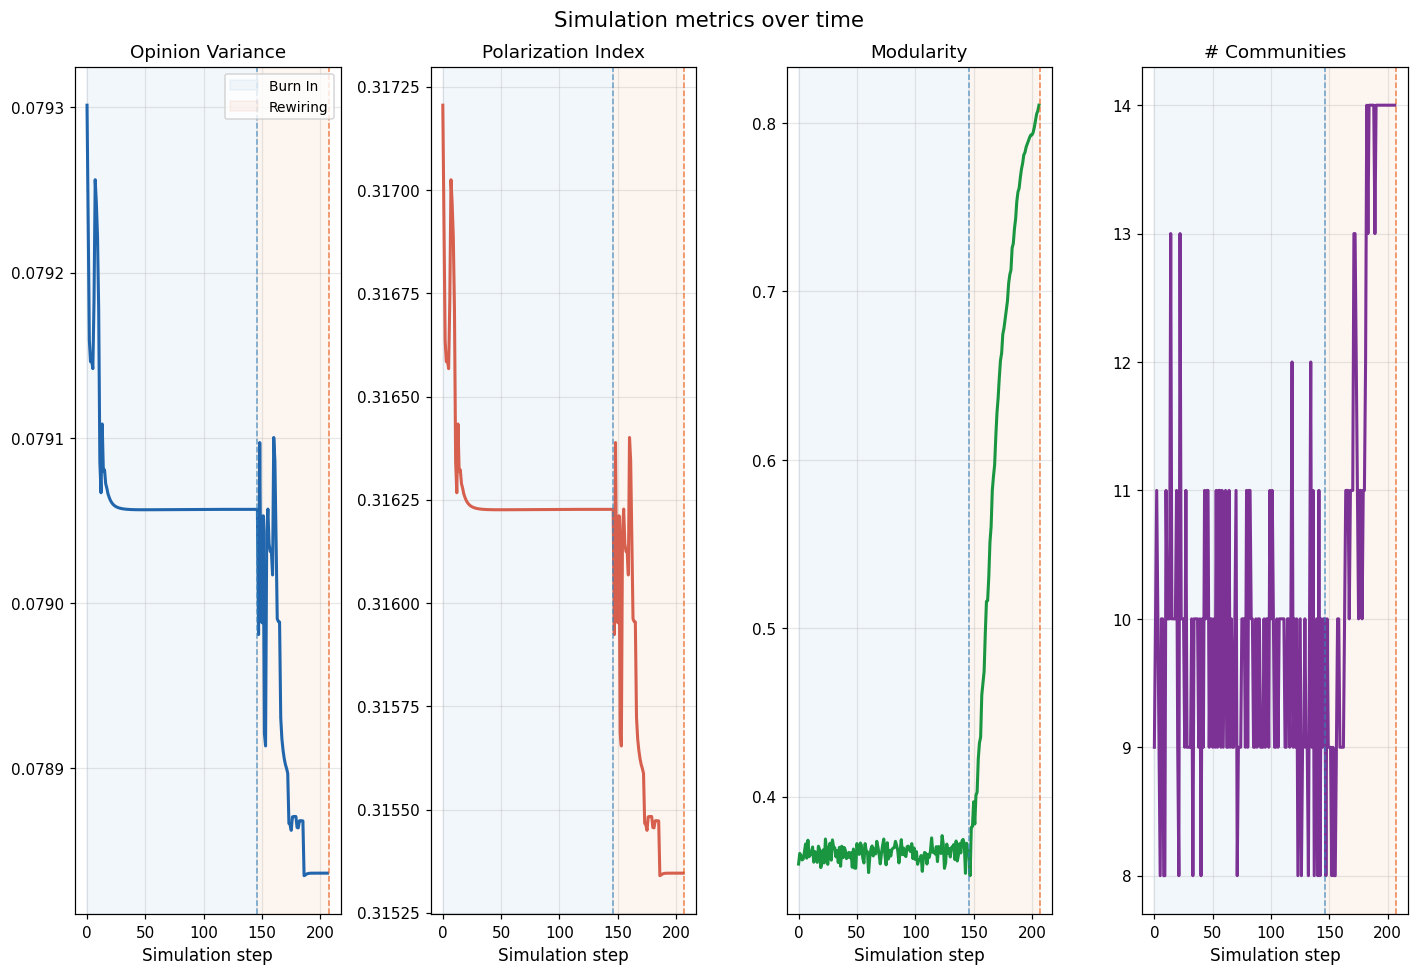

In [42]:
plot_metrics(result)

### Histogram before and after rewiring

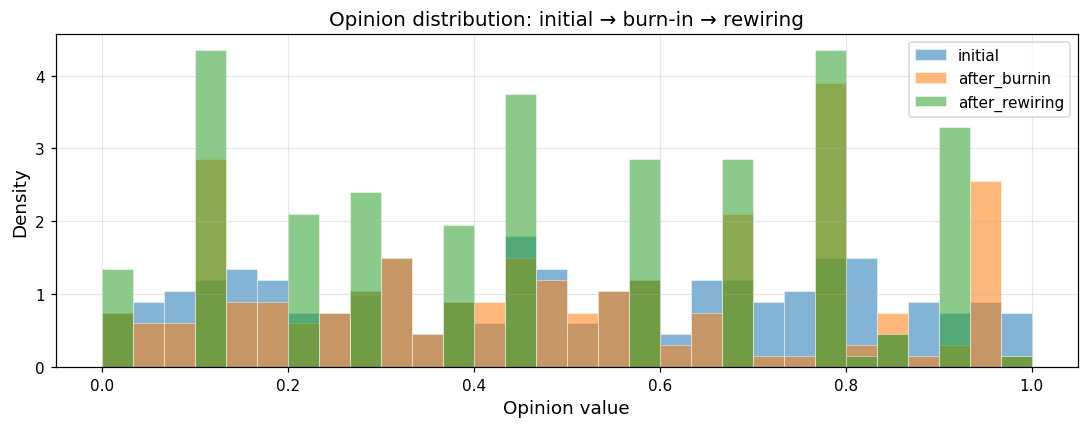

In [43]:
plot_opinion_histogram({
    label: op for label, op in result["snapshots"]
}, title="Opinion distribution: initial → burn-in → rewiring")

---
## 4 · Network Model Comparison

Does topology matter? We apply the same experiment to ER, BA, and WS networks and compare the final polarization.

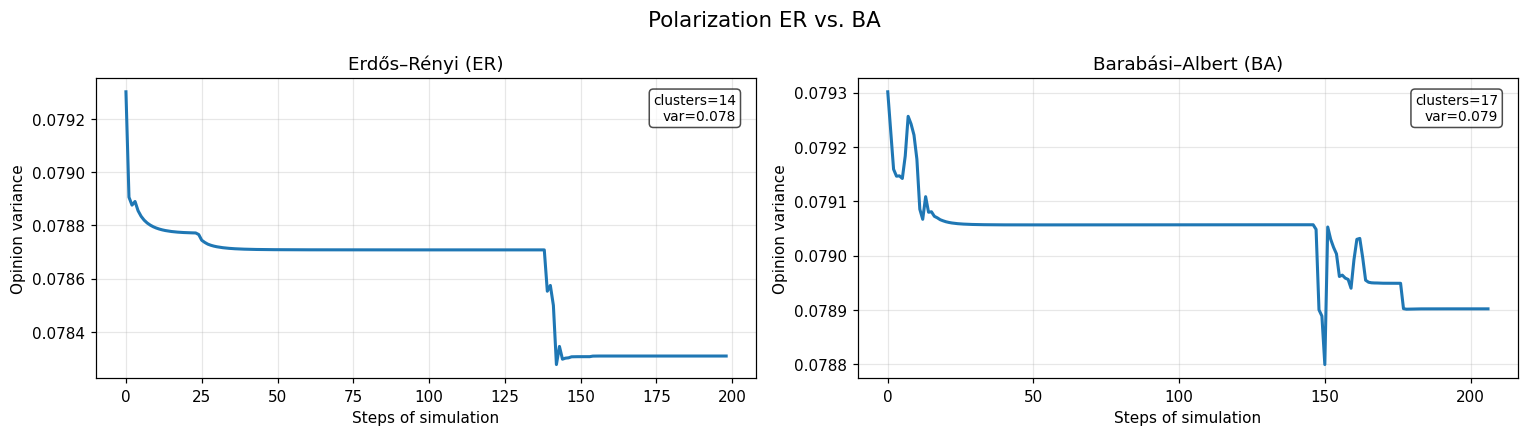

In [44]:
networks = {
    "Erdős–Rényi (ER)": make_network("ER", n=200, p=0.04, opinion="uniform", seed=42),
    "Barabási–Albert (BA)": make_network("BA", n=200, m=3, opinion="uniform", seed=42),
}

SIM_PARAMS = dict(epsilon=0.05, rewire=True, p_rewire=0.08,
                  rewire_steps=60, hk_steps_per_rewire=5, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, Gnet) in zip(axes, networks.items()):
    r = run_simulation(Gnet, **SIM_PARAMS)
    var_series = r["metrics"]["opinion_variance"]
    ax.plot(var_series, linewidth=2)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("Steps of simulation")
    ax.set_ylabel("Opinion variance")
    ax.grid(True, alpha=0.3)
    final_op = r["snapshots"][-1][1]
    ax.text(0.97, 0.95,
            f"clusters={n_clusters(final_op)}\nvar={opinion_variance(final_op):.3f}",
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, bbox=dict(boxstyle='round', fc='white', alpha=0.7))

plt.suptitle("Polarization ER vs. BA", fontsize=14)
plt.tight_layout()
plt.show()

---
## 5 · Sandbox — experimenta libremente

Usa esta celda para probar combinaciones de parámetros.

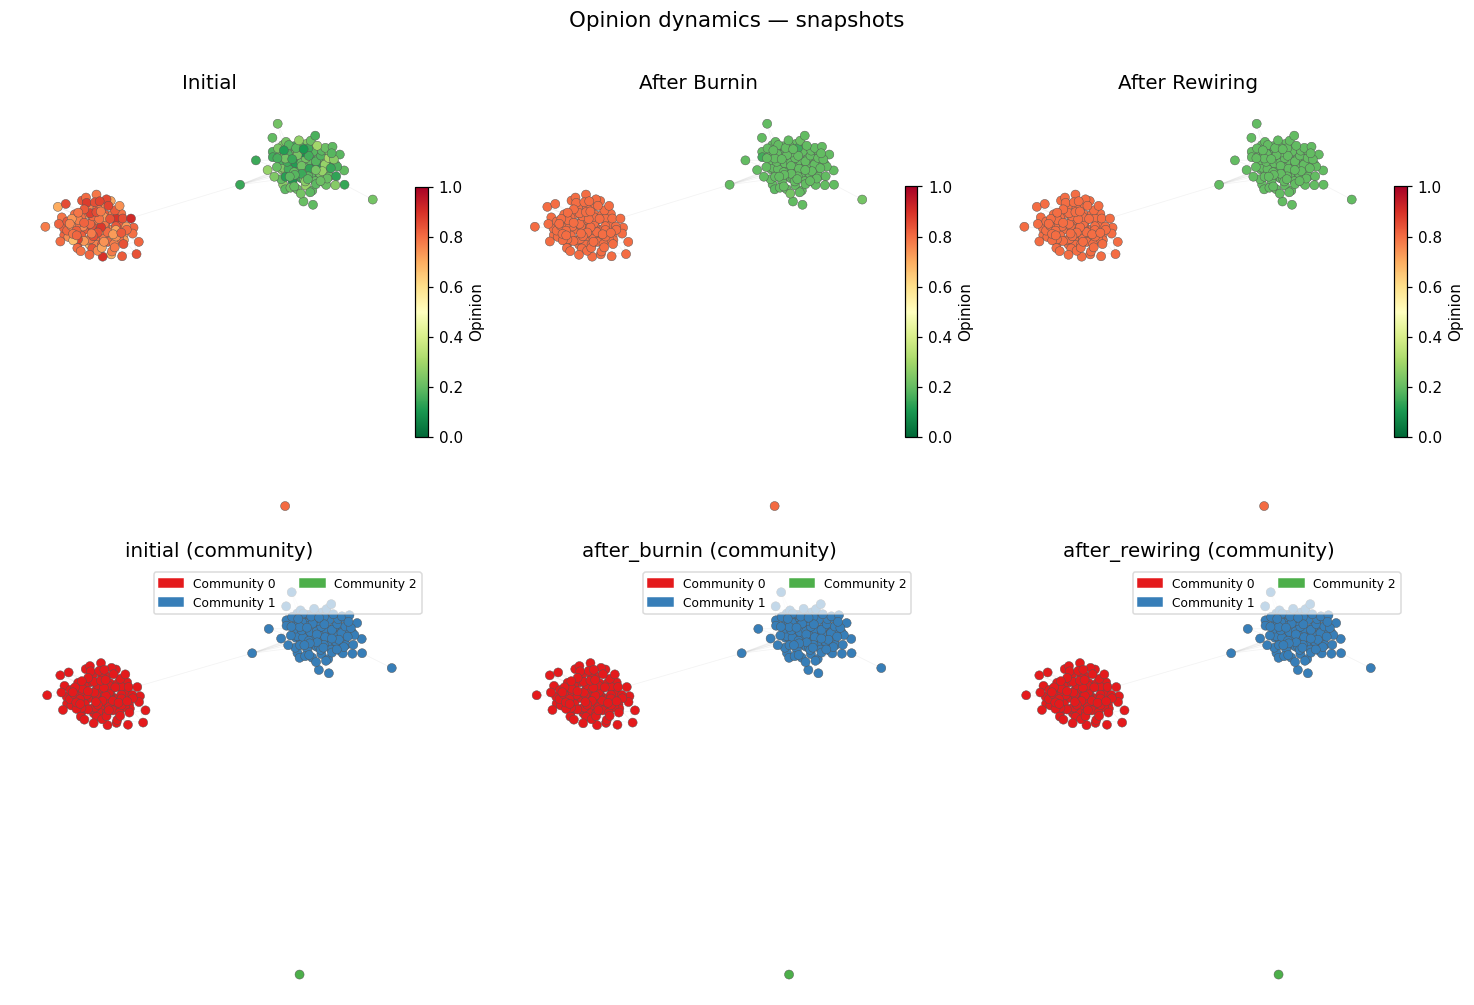

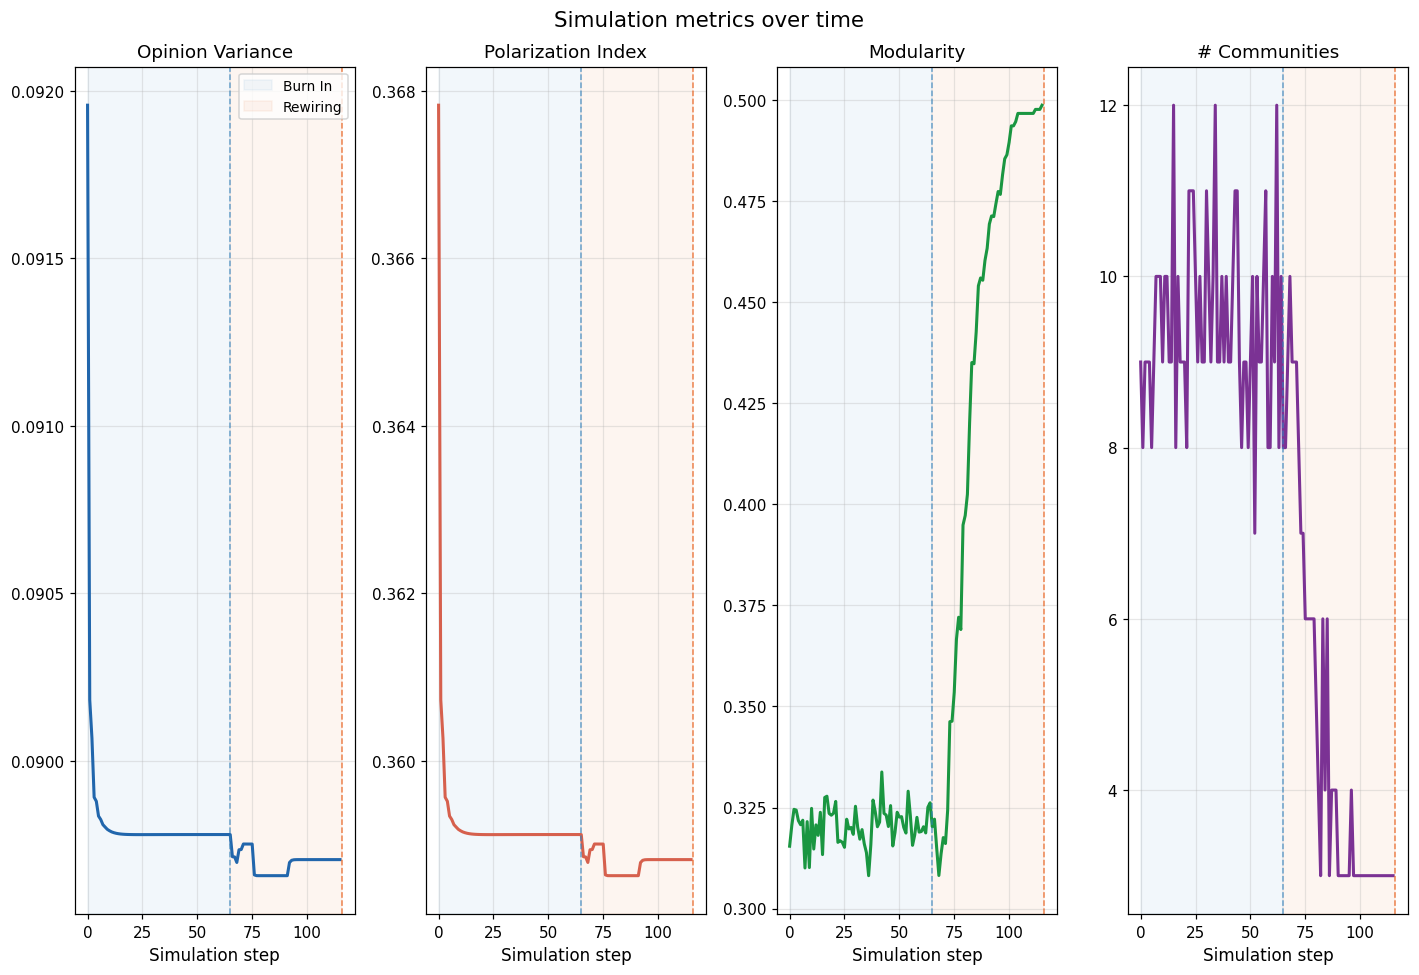

In [45]:
# --- Cambia lo que quieras aquí ---
G_exp = make_network(
    model   = "BA",       # "ER" | "BA" | "WS"
    n       = 250,
    m       = 4,
    opinion = "bimodal",  # "uniform" | "bimodal" | "clustered"
    seed    = 7,
)

r_exp = run_simulation(
    G_exp,
    epsilon             = 0.20,
    rewire              = True,
    p_rewire            = 0.10,
    rewire_steps        = 50,
    hk_steps_per_rewire = 5,
    seed                = 7,
)

plot_snapshots(r_exp["G"], r_exp["snapshots"], color_by="both")
plot_metrics(r_exp)